# QLoRA Fine-Tuning to Generate Stories

In this notebook, we want to create a large language model which will recieve instructions on the topic, theme, word count, number of paragraphs, and complexity, and generate a story which matches this categories.

The right technique for this task is **supervised fine-tuning**, which is designed to take a pretrained large language model which predicts the next token and fine-tunes the model on instruction data prepended to the desired response.

We use both the [SimpleStories dataset](https://huggingface.co/datasets/SimpleStories/SimpleStories) as well as the associated small 35 million parameter [model](https://huggingface.co/SimpleStories/SimpleStories-35M) which we will train via the SFTTrainer class to produce a instruction tuned model. Parts of this script have been adapted from [Microsoft Phi Cookbook](https://github.com/microsoft/PhiCookBook/tree/main).

## Install and load libraries

We use the following libraries:
- **datasets** - provides API for downloading datasets
- **transformers** - provides API for downloading and training of LLMs
- **bitsandbytes** - used for quantizing models
- **trl** - used for reinforcement learning
- **flash_attn** - used for efficient calculation of the attention blocks

Additionally, we use **huggingface_hub** for uploading our trained model and **wandb** (Weights & Biases) for experiment tracking.


In [ ]:
# '-qqq' is an option that makes the output of the command less verbose.
# '--upgrade' is an option that upgrades all specified packages to the newest available version.
# !pip install -qqq --upgrade bitsandbytes transformers peft accel
!pip install -qqq --upgrade bitsandbytes transformers datasets trl flash_attn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 73.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 134.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375.8/375.8 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 112.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 664.8/664.8 MB 194.2 MB/s eta 0:00:01

We load the following libraries and modules.

In [ ]:
import torch
import math
import random
from datetime import datetime
from datasets import load_dataset

from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model, TaskType, PeftModel, PeftConfig
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    set_seed,
    pipeline
)
from trl import SFTTrainer, SFTConfig, setup_chat_format

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

from huggingface_hub import notebook_login
import wandb

We login to Huggingface for uploading the fine-tuned LoRA adapter.

We also login to Weights & Biases for experiment logging and tracking.

In [ ]:
# 'notebook_login' is a function from the 'huggingface_hub' library that logs you into the Hugging Face Model Hub from a Jupyter notebook.
notebook_login()

In [ ]:
wandb.login()

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: volfenstein (volfenstein-ruhr-universit-t-bochum) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Setting global parameters

In [ ]:
# Set the pretrained base model
# base_model = "facebook/opt-125m"
# base_model = "facebook/opt-350m"
# base_model = "facebook/opt-1.3b"
# base_model = "facebook/opt-2.7b"
# base_model = "facebook/opt-6.7b"
base_model = "SimpleStories/SimpleStories-35M"
# base_model = "microsoft/Phi-4-mini-instruct"

# 'new_model' is the name of our fine-tuned model
new_model = "LORA-simple-stories-generator-v2"

# 'hf_model_repo' is the identifier for the Hugging Face repository where you want to save the fine-tuned model.
hf_model_repo="volfenstein/"+new_model
hf_adapter_repo="volfenstein/"+new_model+"-adapter"

# Bits and Bytes configuration for the model
# 'use_4bit' is a boolean that controls whether 4-bit precision should be used for loading the base model.
use_4bit = True
# 'bnb_4bit_compute_dtype' is the data type that should be used for computations with the 4-bit base model.
bnb_4bit_compute_dtype = "bfloat16"
# 'bnb_4bit_quant_type' is the type of quantization that should be used for the 4-bit base model
bnb_4bit_quant_type = "nf4"
# 'use_double_quant' is a boolean that controls whether nested quantization should be used for the 4-bit base model.
use_double_quant = True

# LoRA configuration for the model
# 'lora_r' is the dimension of the LoRA attention.
lora_r = 128
# 'lora_alpha' is the alpha parameter for LoRA scaling.
lora_alpha = 128
# 'lora_dropout' is the dropout probability for LoRA layers.
lora_dropout = 0.05
# 'target_modules' is a list of the modules that should be targeted by LoRA.
# target_modules= ['k_proj', 'q_proj', 'v_proj', 'o_proj', "gate_proj", "down_proj", "up_proj"]
target_modules = "all-linear"
# If we add special tokens via a chat template, we must add 'embed_token' to the modules to save
modules_to_save = ["lm_head", "embed_token"]

# For reproducabilty, set a random seed
set_seed(42)

## Load the dataset: SimpleStories

We use a synthetic dataset of generated stories. It already includes helpful annotations for many features, which we will make use of for converting a model to receive some of these features as instructions for generating the story.

Begin by loading the dataset.

In [ ]:
ds = load_dataset("SimpleStories/SimpleStories")

# We remove outliers from the dataset
ds["train"] = ds["train"].filter(lambda row: 75 <= row["word_count"] <= 525 and 0 <= row["flesch_kincaid_grade"] <= 7)
ds["test"] = ds["test"].filter(lambda row: 75 <= row["word_count"] <= 525 and 0 <= row["flesch_kincaid_grade"] <= 7)

# We will only train with a sample of the dataset.
#sample_size = 10000
#if len(ds["train"]) > sample_size:
#  ds["train"] = ds["train"].select(random.sample(range(len(ds["train"])), sample_size))
#else:
#  print("Warning: Training dataset is smaller than the requested sample size. Using the entire dataset.")

# For testing the training process, helpful to start with a fraction of the dataset
ds["train"] = ds["train"].shard(3, 1, contiguous=True)
ds["test"] = ds["test"].shard(3, 1, contiguous=True)

# Remove the unneeded columns
ds["train"] = ds["train"].remove_columns(['avg_word_length', 'num_paragraphs', 'style', 'feature', 'grammar', 'persona', 'initial_word_type', 'initial_letter', 'character_count', 'avg_sentence_length', 'flesch_reading_ease', 'dale_chall_readability_score', 'num_stories_in_completion', 'expected_num_stories_in_completion', 'generation_id', 'model'])
ds["test"] = ds["test"].remove_columns(['avg_word_length', 'num_paragraphs', 'style', 'feature', 'grammar', 'persona', 'initial_word_type', 'initial_letter', 'character_count', 'avg_sentence_length', 'flesch_reading_ease', 'dale_chall_readability_score', 'num_stories_in_completion', 'expected_num_stories_in_completion', 'generation_id', 'model'])

Filter:   0%|          | 0/2115696 [00:00<?, ? examples/s]

Filter:   0%|          | 0/21371 [00:00<?, ? examples/s]

In [ ]:
def display_table(dataset_or_sample):
    # A helper fuction to display a Transformer dataset or single sample. Displays multi-line strings.
    pd.set_option("display.max_colwidth", None)
    pd.set_option("display.width", None)
    pd.set_option("display.max_rows", None)

    if isinstance(dataset_or_sample, dict):
        df = pd.DataFrame(dataset_or_sample, index=[0])
    else:
        df = pd.DataFrame(dataset_or_sample)

    html = df.to_html().replace("\\n", "<br>")
    styled_html = f"""<style> .dataframe th, .dataframe tbody td {{ text-align: left; padding-right: 30px; }} </style> {html}"""
    display(HTML(styled_html))


display_table(ds["train"].select(range(3)))

,story,topic,theme,word_count,flesch_kincaid_grade
0,"Mysterious laughter echoed from the art room. Jose was painting alone when he heard his classmates giggling outside. He wondered what was so funny. Peeking out, he saw a group making fun of Kim's painting. His heart sank; he liked Kim and her art. As the laughter grew louder, Jose felt a fire in his chest. He knew he had to do something. Gathering his courage, he stepped outside. ""Stop it!"" he shouted, surprising everyone. ""Kim works hard on her art. You should respect her!"" The group fell silent, looking at him in shock. Kim's face turned red, but then she smiled gratefully at Jose. He felt proud. Slowly, some of the others began to nod. ""You're right,"" one said. ""We should support her instead."" In that moment, Jose learned the power of trust and friendship. Standing up for what is right made him feel strong. Together, they all went back to the art room, ready to admire Kim's beautiful work. Trust, he realized, can change hearts.",school life,Trust,215,2.9
1,"Sand slipped through fingers as a child built a castle by the sea. Each grain held a wish, and each wave brought dreams. ""What if my castle washes away?"" he worried, but deep inside, he held onto hope. The sea whispered stories of strength and magic, encouraging him to create without fear. One day, as the sun dipped low, a mermaid appeared in the water. ""Your castle is strong,"" she sang. ""It holds the dreams of your heart."" The boy stared in awe, feeling the spark of hope growing within him. The mermaid swirled around, leaving trails of light in the water, showing him that beauty comes from daring to dream.With a renewed spirit, the boy worked on his castle. He added seashells and colorful stones, making it a place of magic. When the tide came in, he watched with wonder as the water danced around his creation. Instead of fear, he felt joy. He realized that even if his castle washed away, the joy of creating would always stay in his heart. Hope, like the waves, would always return.",the arts,Hope,220,4.2
2,"From the first light of dawn, a girl named Mia sat by the river. The water flowed gently, reflecting the colors of the sky. She often thought about the boy from the village across the hill. His name was Leo, and he had the brightest smile. Each time she saw him, her heart beat faster than before. Yet, they never spoke, as the river kept them apart. One day, Mia found a small, silver locket by the water. It was cold and shiny, unlike anything she had ever seen. She picked it up and opened it, revealing a tiny picture of a boy. It looked like Leo! Mia felt a rush of hope. Could it be a sign? With the locket in her hand, she decided to walk up the hill to Leo's village. The closer she got, the more her heart raced. She imagined how happy she would be if he noticed her. When she reached the village, she saw Leo sitting under a big tree, reading a book. Mia gathered her courage and walked up to him. She held out the locket, her voice shaking. ""I found this by the river,"" she said. Leo looked up, surprised. His eyes sparkled with wonder. ""It's mine!"" he exclaimed, smiling widely. As they talked, Mia learned that the locket had been lost long ago. Leo told her stories about his adventures and dreams. They laughed together, and the river no longer felt like a wall between them. Days turned into weeks, and they met every day. Mia and Leo grew closer, sharing secrets and laughter. One evening, as the sun set, Leo took Mia's hand. ""You are more special than the river,"" he whispered. Mia's heart sang with joy.But then, one morning, Mia found the locket broken. She was sad, thinking it was a bad sign. Yet, Leo reassured her, ""It is not the locket that matters. It is our hearts."" And in that moment, she realized their love was stronger than anything else.",bygone eras,Romance,413,2.3


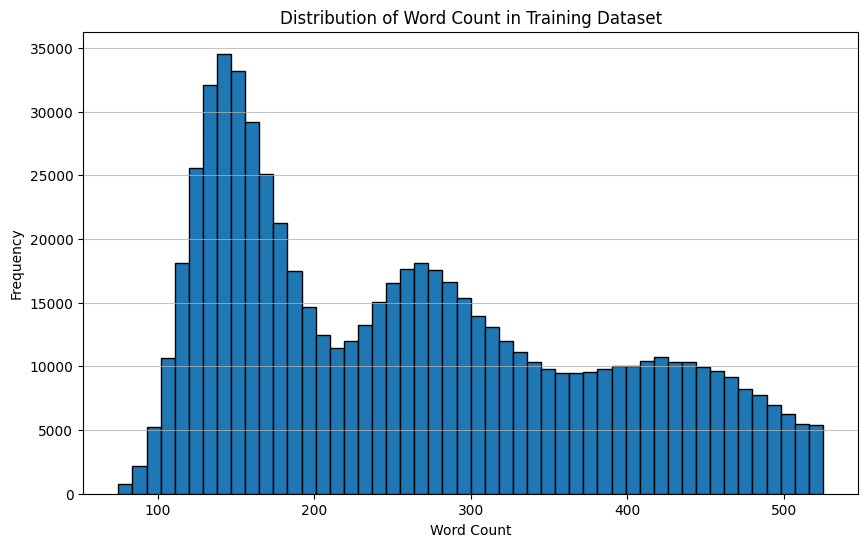

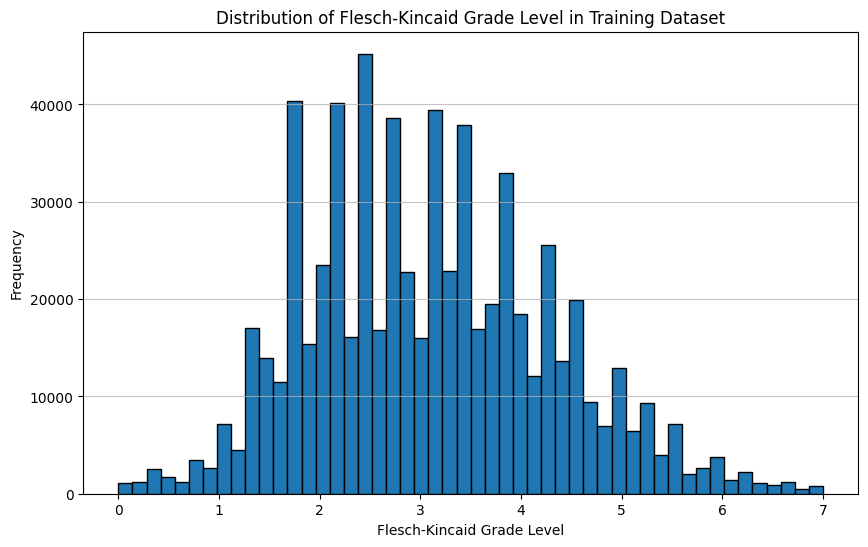

In [ ]:
# Convert the dataset to a pandas DataFrame to easily plot the distribution
df_train = ds["train"].to_pandas()

# Plot the distribution of word_count
plt.figure(figsize=(10, 6))
plt.hist(df_train['word_count'], bins=50, edgecolor='black')
plt.title('Distribution of Word Count in Training Dataset')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Plot the distribution of flesch_kincaid_grade
plt.figure(figsize=(10, 6))
plt.hist(df_train['flesch_kincaid_grade'], bins=50, edgecolor='black')
plt.title('Distribution of Flesch-Kincaid Grade Level in Training Dataset')
plt.xlabel('Flesch-Kincaid Grade Level')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
print("\nFrequency of 'topic' values:")
print(df_train['topic'].value_counts())

print("\nFrequency of 'theme' values:")
print(df_train['theme'].value_counts())


Frequency of 'topic' values:
topic
talking animals             14731
magical objects             14633
holidays                    14581
hidden treasures            14532
cultural traditions         14466
fairy tales                 14461
fantasy worlds              14414
riddles                     14333
a deadline or time limit    14333
unusual vehicles            14314
snowy adventures            14284
miniature worlds            14272
undercover missions         14244
superheroes                 14243
seasonal changes            14217
magical lands               14212
the sky                     14172
time travel                 14161
island adventures           14155
royal kingdoms              14147
invisibility                14146
shape-shifting              14128
living objects              14125
the arts                    14108
gardens                     14106
bygone eras                 14088
virtual worlds              14079
robots and technology       14068
secret socie

We want to format the columns "topic", "theme", "word_count", "flesch_kincaid_grade" into a user prompt, which the fine-tuned model will receive to generate the subsequent story. To make the fine-tuned model's life easier, we don't need the full resolution of the wordcount; the fine-tuned model will infer the relationship. We also round the complexity grade.

In [ ]:
PROMPT_TEMPLATE = """Topic: {topic}

Theme: {theme}

Wordcount: {wordcount}

Complexity: {complexity}"""


def apply_prompt_template(row):
    prompt = PROMPT_TEMPLATE.format(
        topic=row["topic"],
        theme=row["theme"],
        wordcount= 25 * (row["word_count"] // 25),
        complexity=round(row["flesch_kincaid_grade"]),
    )
    return {"user_prompt": prompt}


ds_train = ds["train"].map(apply_prompt_template)
ds_test = ds["test"].map(apply_prompt_template)
display_table(ds_train.select(range(1)))

Map:   0%|          | 0/675146 [00:00<?, ? examples/s]

Map:   0%|          | 0/6818 [00:00<?, ? examples/s]

,story,topic,theme,word_count,flesch_kincaid_grade,user_prompt
0,"Mysterious laughter echoed from the art room. Jose was painting alone when he heard his classmates giggling outside. He wondered what was so funny. Peeking out, he saw a group making fun of Kim's painting. His heart sank; he liked Kim and her art. As the laughter grew louder, Jose felt a fire in his chest. He knew he had to do something. Gathering his courage, he stepped outside. ""Stop it!"" he shouted, surprising everyone. ""Kim works hard on her art. You should respect her!"" The group fell silent, looking at him in shock. Kim's face turned red, but then she smiled gratefully at Jose. He felt proud. Slowly, some of the others began to nod. ""You're right,"" one said. ""We should support her instead."" In that moment, Jose learned the power of trust and friendship. Standing up for what is right made him feel strong. Together, they all went back to the art room, ready to admire Kim's beautiful work. Trust, he realized, can change hearts.",school life,Trust,215,2.9,Topic: school lifeTheme: TrustWordcount: 200Complexity: 3


## Load the base model and tokenizer

To begin, we determine if our GPU supports training with BF16.

In [ ]:
# 'torch.cuda.is_bf16_supported()' is a function that checks if BF16 is supported on the current GPU. BF16 is a data type that uses 16 bits, like float16, but allocates more bits to the exponent, which can result in higher precision.
# 'compute_dtype' is a variable that will hold the data type to be used for computations.
# 'attn_implementation' is a variable that will hold the type of attention implementation to be used.

if torch.cuda.is_bf16_supported():
    compute_dtype = torch.bfloat16
    attn_implementation = 'flash_attention_2'
else:
    compute_dtype = torch.float16
    attn_implementation = 'sdpa'

print(attn_implementation)
print(compute_dtype)

flash_attention_2
torch.bfloat16


These pretrained base models sometimes do not have a chat format specified for the tokenizer, so we need to set this with a call to [setup_chat_format()](https://huggingface.co/docs/trl/main/en/sft_trainer#add-special-tokens-for-chat-format).

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(base_model, trust_remote_code=True, add_eos_token=True, use_fast=True)
tokenizer.pad_token = tokenizer.unk_token
tokenizer.pad_token_id = tokenizer.convert_tokens_to_ids(tokenizer.pad_token)
tokenizer.padding_side = 'left'

bnb_config = BitsAndBytesConfig(
        load_in_4bit=use_4bit,
        bnb_4bit_quant_type=bnb_4bit_quant_type,
        bnb_4bit_compute_dtype=compute_dtype,
        bnb_4bit_use_double_quant=use_double_quant,
)

# This is the model we will train
model = AutoModelForCausalLM.from_pretrained(
          base_model, torch_dtype=compute_dtype, trust_remote_code=True, quantization_config=bnb_config, device_map="auto",
          attn_implementation=attn_implementation
)
model = prepare_model_for_kbit_training(model)

model, tokenizer = setup_chat_format(model, tokenizer)

loading file tokenizer.json from cache at /root/.cache/huggingface/hub/models--SimpleStories--SimpleStories-35M/snapshots/c1bf9eb6b679f96e682b410b3a376de9fb896c79/tokenizer.json
loading file tokenizer.model from cache at None
loading file added_tokens.json from cache at None
loading file special_tokens_map.json from cache at /root/.cache/huggingface/hub/models--SimpleStories--SimpleStories-35M/snapshots/c1bf9eb6b679f96e682b410b3a376de9fb896c79/special_tokens_map.json
loading file tokenizer_config.json from cache at /root/.cache/huggingface/hub/models--SimpleStories--SimpleStories-35M/snapshots/c1bf9eb6b679f96e682b410b3a376de9fb896c79/tokenizer_config.json
loading file chat_template.jinja from cache at None
loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--SimpleStories--SimpleStories-35M/snapshots/c1bf9eb6b679f96e682b410b3a376de9fb896c79/config.json
Model config LlamaConfig {
  "architectures": [
    "LlamaForCausalLM"
  ],
  "attention_bias": fa

## Formatting the dataset as a chat template

The SFTTrainer expects the data in a specific [format](https://huggingface.co/docs/trl/en/sft_trainer#dataset-format-support). Specifically, each entry should be message is a dictionary containing 2 keys, namely:

* "role": specifies who the creator of the message is (could be "system", "assistant" or "user" - the latter referring to a human).
* "content": the actual content of the message.

We take a moment to reformat the data and check the results are as expected.

In [ ]:
def apply_chat_template(row):
    # messages = [{"prompt": row["prompt"], "completion": row["story"]}]
    messages = [
        {"role": "user", "content": row["user_prompt"]},
        {"role": "assistant", "content": row["story"]}
        ]
    return {"messages": messages}

ds_train_chat = ds_train.map(apply_chat_template)
ds_test_chat = ds_test.map(apply_chat_template)

display_table(ds_train_chat.select(range(1)))

Map:   0%|          | 0/675146 [00:00<?, ? examples/s]

Map:   0%|          | 0/6818 [00:00<?, ? examples/s]

,story,topic,theme,word_count,flesch_kincaid_grade,user_prompt,messages
0,"Mysterious laughter echoed from the art room. Jose was painting alone when he heard his classmates giggling outside. He wondered what was so funny. Peeking out, he saw a group making fun of Kim's painting. His heart sank; he liked Kim and her art. As the laughter grew louder, Jose felt a fire in his chest. He knew he had to do something. Gathering his courage, he stepped outside. ""Stop it!"" he shouted, surprising everyone. ""Kim works hard on her art. You should respect her!"" The group fell silent, looking at him in shock. Kim's face turned red, but then she smiled gratefully at Jose. He felt proud. Slowly, some of the others began to nod. ""You're right,"" one said. ""We should support her instead."" In that moment, Jose learned the power of trust and friendship. Standing up for what is right made him feel strong. Together, they all went back to the art room, ready to admire Kim's beautiful work. Trust, he realized, can change hearts.",school life,Trust,215,2.9,Topic: school lifeTheme: TrustWordcount: 200Complexity: 3,"[{'content': 'Topic: school life Theme: Trust Wordcount: 200 Complexity: 3', 'role': 'user'}, {'content': 'Mysterious laughter echoed from the art room. Jose was painting alone when he heard his classmates giggling outside. He wondered what was so funny. Peeking out, he saw a group making fun of Kim's painting. His heart sank; he liked Kim and her art. As the laughter grew louder, Jose felt a fire in his chest. He knew he had to do something. Gathering his courage, he stepped outside. ""Stop it!"" he shouted, surprising everyone. ""Kim works hard on her art. You should respect her!"" The group fell silent, looking at him in shock. Kim's face turned red, but then she smiled gratefully at Jose. He felt proud. Slowly, some of the others began to nod. ""You're right,"" one said. ""We should support her instead."" In that moment, Jose learned the power of trust and friendship. Standing up for what is right made him feel strong. Together, they all went back to the art room, ready to admire Kim's beautiful work. Trust, he realized, can change hearts.', 'role': 'assistant'}]"


In [ ]:
input_text = tokenizer.apply_chat_template(ds_train_chat[0]["messages"], tokenize=False)

# Let's check that everything looks good
print(input_text)

<|im_start|>user
Topic: school life

Theme: Trust

Wordcount: 200

Complexity: 3<|im_end|>
<|im_start|>assistant
Mysterious laughter echoed from the art room. Jose was painting alone when he heard his classmates giggling outside. He wondered what was so funny. Peeking out, he saw a group making fun of Kim's painting. His heart sank; he liked Kim and her art. 

As the laughter grew louder, Jose felt a fire in his chest. He knew he had to do something. Gathering his courage, he stepped outside. "Stop it!" he shouted, surprising everyone. "Kim works hard on her art. You should respect her!" 

The group fell silent, looking at him in shock. Kim's face turned red, but then she smiled gratefully at Jose. He felt proud. Slowly, some of the others began to nod. "You're right," one said. "We should support her instead." 

In that moment, Jose learned the power of trust and friendship. Standing up for what is right made him feel strong. Together, they all went back to the art room, ready to admi

This is exactly the format of text to be fed to the tokenizer and for fine-tuning the model. It will be trained to predict the next token of the tokenized formatted text.

## Inference using the Base Model

To provide a baseline, we examine the output of the base model prior to any training. We also compute the perplexity of the base model on the dataset.

In [ ]:
pipe = pipeline(model=model, tokenizer=tokenizer, task="text-generation")

sample = ds_test[1]
prompt = PROMPT_TEMPLATE.format(
    theme=sample["theme"], topic=sample["topic"], wordcount=25 * (sample["word_count"] // 25), complexity=round(sample["flesch_kincaid_grade"])
)

with torch.no_grad():
    response = pipe([{"role": "user", "content": prompt}], max_new_tokens=512, repetition_penalty=1.15, return_full_text=False)

display_table({"user_prompt": prompt, "generated_story": response[0]["generated_text"]})

Device set to use cuda:0
/usr/local/lib/python3.11/dist-packages/bitsandbytes/autograd/_functions.py:383: UserWarning: Some matrices hidden dimension is not a multiple of 64 and efficient inference kernels are not supported for these (slow). Matrix input size found: torch.Size([1, 1, 1365])
  warn(


,user_prompt,generated_story
0,Topic: holidaysTheme: PlanningWordcount: 225Complexity: 4,". a thought flashed through her mind, and she began to write about two friends who built a bridge over the river. they used nature to connect their land to the water. "" they knew that with each season, they were responsible for it, "" she wrote. in her story, the friends learned to plan carefully. they gathered flowers and made a new bridge. when the bridge was finished, it stood strong against the wind. the river sparkled under the sun, and everyone felt proud of their work. the girl smiled, realizing how important it is to care for one another and build strong friendships. quickly, a boy named alex sat by the fireplace. he had heard stories of a lost treasure on an island that no one could find anymore. they said it was hidden deep in the jungle. but there was a warning : if you disturbed, you must turn back. fear gripped him, yet curiosity tugged at his heart. determined, he set out into the forest, where trees towered high above. the deeper he went, the more mysterious. shadows flickered, and strange sounds echoed around him. suddenly, he stumbled upon a clearing filled with ancient stones. each stone seemed to tell a different story, a tale waiting to be told. feeling brave, alex knelt down to explore. each stone held a clue, leading him deeper into the forest. after hours of walking, he found a small cave. inside, he discovered a chest, dusty and old. his heart raced as he opened it, expecting riches. instead, it was filled with old maps and letters. he realized these were the treasures of sailors long gone. the true treasure was knowledge, waiting to be uncovered. alex read the letters, feeling their dreams and fears. he understood then that some treasures are meant to be left undisturbed. the adventure taught him that seeking wealth can lead to great discoveries. he decided to leave the map behind, choosing adventure over gold instead. joyful sounds echoed through the streets of dreamland. samuel, a playful boy, loved to tell jokes. today, he saw a group of children playing games. they looked so happy! he wanted to join, but he felt shy. in truth, he was shy. with each laugh and cheer, he felt stronger. "" here's a riddle for me! "" he called out. "" what has keys but can't open locks? "" the children paused and scratched their heads. then a girl shouted, "" a piano!"


## Supervised Fine-Tuning with QLoRA

We will use the [SFTTrainer](https://huggingface.co/docs/trl/sft_trainer) to fine-tune our model. SFTTrainer is a subclass of the Trainer from the transformers library and supports the same features, including logging, evaluation, and checkpointing, but adds additiional quality of life features, including:
* Dataset formatting, including conversational and instruction format
* Training on completions only, ignoring prompts
* Packing datasets for more efficient training
* PEFT (parameter-efficient fine-tuning) support including Q-LoRA
* Preparing the model and tokenizer for conversational fine-tuning (e.g. adding special tokens)

See [here](https://huggingface.co/docs/trl/v0.12.2/en/sft_trainer#trl.SFTConfig) for more information on the parameters for SFTconfig().

In [ ]:
# Get the current timestamp
current_time = datetime.now()

# Create a readable timestamp
formatted_time = current_time.strftime("%b-%d-%Y-%H-%M-%S")

# Create a name for the run
wandb_run_name = f"FT_simple_stories_lora_v2_run_{formatted_time}"

fine_tuned_model_name = "lora-simple-stories-generator-v2"

args = SFTConfig(
        output_dir="./phi-4-mini-QLoRA",
        # evaluation_strategy="steps",
        # do_eval=True,
        # eval_steps=100,
        optim="adamw_torch",
        per_device_train_batch_size=32,
        gradient_accumulation_steps=4,
        per_device_eval_batch_size=8,
        log_level="debug",
        save_strategy="epoch",
        logging_steps=10,
        learning_rate=1e-4,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        num_train_epochs=1,
        #max_steps=3000,  # Adjust based on dataset size and desired training duration
        warmup_ratio=0.1,
        lr_scheduler_type="linear",
        completion_only_loss=True,
        hub_model_id=fine_tuned_model_name,  # Set a unique name for your model - used for HuggingFace hub
        report_to="wandb",
        run_name = wandb_run_name,
)

peft_config = LoraConfig(
        r=lora_r,
        lora_alpha=lora_alpha,
        lora_dropout=lora_dropout,
        task_type=TaskType.CAUSAL_LM,
        modules_to_save=modules_to_save,
        target_modules=target_modules,
)

peft_model = get_peft_model(model, peft_config)
peft_model.print_trainable_parameters()

PyTorch: setting up devices


trainable params: 15,859,200 || all params: 50,994,176 || trainable%: 31.1000


In [ ]:
trainer = SFTTrainer(
        model=peft_model,
        train_dataset=ds_train_chat,
        eval_dataset=ds_test_chat,
        peft_config=peft_config,
        processing_class=tokenizer,
        args=args,
)

Converting train dataset to ChatML:   0%|          | 0/675146 [00:00<?, ? examples/s]

Applying chat template to train dataset:   0%|          | 0/675146 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/675146 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/675146 [00:00<?, ? examples/s]

Converting eval dataset to ChatML:   0%|          | 0/6818 [00:00<?, ? examples/s]

Applying chat template to eval dataset:   0%|          | 0/6818 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/6818 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/6818 [00:00<?, ? examples/s]

Using auto half precision backend
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [ ]:
trainer.train()

Currently training with a batch size of: 32
The following columns in the Training set don't have a corresponding argument in `PeftModelForCausalLM.forward` and have been ignored: theme, token_type_ids, word_count, flesch_kincaid_grade, story, text, topic, user_prompt. If theme, token_type_ids, word_count, flesch_kincaid_grade, story, text, topic, user_prompt are not expected by `PeftModelForCausalLM.forward`,  you can safely ignore this message.
***** Running training *****
  Num examples = 675,146
  Num Epochs = 1
  Instantaneous batch size per device = 32
  Total train batch size (w. parallel, distributed & accumulation) = 128
  Gradient Accumulation steps = 4
  Total optimization steps = 5,275
  Number of trainable parameters = 15,859,200
Automatic Weights & Biases logging enabled, to disable set os.environ["WANDB_DISABLED"] = "true"
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be pas

Step,Training Loss
10,2.203700
20,2.142300
30,2.035800
40,1.896000
50,1.775000
60,1.685500
70,1.616300
80,1.574700
90,1.529200
100,1.528800


Saving model checkpoint to ./phi-4-mini-QLoRA/checkpoint-5275
loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--SimpleStories--SimpleStories-35M/snapshots/c1bf9eb6b679f96e682b410b3a376de9fb896c79/config.json
Model config LlamaConfig {
  "architectures": [
    "LlamaForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 1,
  "eos_token_id": 2,
  "head_dim": 64,
  "hidden_act": "silu",
  "hidden_size": 512,
  "initializer_range": 0.02,
  "intermediate_size": 1365,
  "max_position_embeddings": 512,
  "mlp_bias": false,
  "model_type": "llama",
  "num_attention_heads": 8,
  "num_hidden_layers": 12,
  "num_key_value_heads": 2,
  "pretraining_tp": 1,
  "rms_norm_eps": 1e-06,
  "rope_scaling": null,
  "rope_theta": 10000.0,
  "tie_word_embeddings": true,
  "torch_dtype": "float32",
  "transformers_version": "4.52.4",
  "use_cache": true,
  "vocab_size": 4096
}

/usr/local/lib/python3.11/dist-packages/peft/utils/save_a

TrainOutput(global_step=5275, training_loss=1.3366431418866342, metrics={'train_runtime': 7023.5519, 'train_samples_per_second': 96.126, 'train_steps_per_second': 0.751, 'total_flos': 1.0963584924672e+17, 'train_loss': 1.3366431418866342})

## Save and upload the adapter and the new model

In [ ]:
peft_model.push_to_hub(hf_adapter_repo)

loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--SimpleStories--SimpleStories-35M/snapshots/c1bf9eb6b679f96e682b410b3a376de9fb896c79/config.json
Model config LlamaConfig {
  "architectures": [
    "LlamaForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 1,
  "eos_token_id": 2,
  "head_dim": 64,
  "hidden_act": "silu",
  "hidden_size": 512,
  "initializer_range": 0.02,
  "intermediate_size": 1365,
  "max_position_embeddings": 512,
  "mlp_bias": false,
  "model_type": "llama",
  "num_attention_heads": 8,
  "num_hidden_layers": 12,
  "num_key_value_heads": 2,
  "pretraining_tp": 1,
  "rms_norm_eps": 1e-06,
  "rope_scaling": null,
  "rope_theta": 10000.0,
  "tie_word_embeddings": true,
  "torch_dtype": "float32",
  "transformers_version": "4.52.4",
  "use_cache": true,
  "vocab_size": 4096
}

/usr/local/lib/python3.11/dist-packages/peft/utils/save_and_load.py:250: UserWarning: Setting `save_embedding_layers` t

adapter_model.safetensors:   0%|          | 0.00/88.6M [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/volfenstein/LORA-simple-stories-generator-v2-adapter/commit/e430f6882a9dda5b54c8462a75f558719d1c3739', commit_message='Upload model', commit_description='', oid='e430f6882a9dda5b54c8462a75f558719d1c3739', pr_url=None, repo_url=RepoUrl('https://huggingface.co/volfenstein/LORA-simple-stories-generator-v2-adapter', endpoint='https://huggingface.co', repo_type='model', repo_id='volfenstein/LORA-simple-stories-generator-v2-adapter'), pr_revision=None, pr_num=None)

In [ ]:
model = AutoModelForCausalLM.from_pretrained(base_model, trust_remote_code=True, torch_dtype=compute_dtype)
tokenizer = AutoTokenizer.from_pretrained(base_model)
model, tokenizer = setup_chat_format(model, tokenizer)

model = PeftModel.from_pretrained(model, hf_adapter_repo)
model = model.merge_and_unload()

model.push_to_hub(hf_model_repo)
tokenizer.push_to_hub(hf_model_repo)

loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--SimpleStories--SimpleStories-35M/snapshots/c1bf9eb6b679f96e682b410b3a376de9fb896c79/config.json
Model config LlamaConfig {
  "architectures": [
    "LlamaForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 1,
  "eos_token_id": 2,
  "head_dim": 64,
  "hidden_act": "silu",
  "hidden_size": 512,
  "initializer_range": 0.02,
  "intermediate_size": 1365,
  "max_position_embeddings": 512,
  "mlp_bias": false,
  "model_type": "llama",
  "num_attention_heads": 8,
  "num_hidden_layers": 12,
  "num_key_value_heads": 2,
  "pretraining_tp": 1,
  "rms_norm_eps": 1e-06,
  "rope_scaling": null,
  "rope_theta": 10000.0,
  "tie_word_embeddings": true,
  "torch_dtype": "bfloat16",
  "transformers_version": "4.52.4",
  "use_cache": true,
  "vocab_size": 4096
}

loading weights file model.safetensors from cache at /root/.cache/huggingface/hub/models--SimpleStories--SimpleStories

adapter_config.json:   0%|          | 0.00/900 [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/88.6M [00:00<?, ?B/s]

Configuration saved in /tmp/tmp0duszjyv/config.json
Configuration saved in /tmp/tmp0duszjyv/generation_config.json
Model weights saved in /tmp/tmp0duszjyv/model.safetensors
Uploading the following files to volfenstein/LORA-simple-stories-generator-v2: README.md,model.safetensors,config.json,generation_config.json


model.safetensors:   0%|          | 0.00/74.5M [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

chat template saved in /tmp/tmpionnet43/chat_template.jinja
tokenizer config file saved in /tmp/tmpionnet43/tokenizer_config.json
Special tokens file saved in /tmp/tmpionnet43/special_tokens_map.json
Uploading the following files to volfenstein/LORA-simple-stories-generator-v2: README.md,special_tokens_map.json,tokenizer_config.json,tokenizer.json,chat_template.jinja


CommitInfo(commit_url='https://huggingface.co/volfenstein/LORA-simple-stories-generator-v2/commit/b22c0a3a0c252c5bdca55abe80ce9db22108d3c2', commit_message='Upload tokenizer', commit_description='', oid='b22c0a3a0c252c5bdca55abe80ce9db22108d3c2', pr_url=None, repo_url=RepoUrl('https://huggingface.co/volfenstein/LORA-simple-stories-generator-v2', endpoint='https://huggingface.co', repo_type='model', repo_id='volfenstein/LORA-simple-stories-generator-v2'), pr_revision=None, pr_num=None)

## Load the adapter into the base model

In [ ]:
config = PeftConfig.from_pretrained(hf_adapter_repo)
model = AutoModelForCausalLM.from_pretrained(base_model, trust_remote_code=True, torch_dtype=compute_dtype)
tokenizer = AutoTokenizer.from_pretrained(base_model)

model, tokenizer = setup_chat_format(model, tokenizer)
model = PeftModel.from_pretrained(model, hf_adapter_repo)

loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--SimpleStories--SimpleStories-35M/snapshots/c1bf9eb6b679f96e682b410b3a376de9fb896c79/config.json
Model config LlamaConfig {
  "architectures": [
    "LlamaForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 1,
  "eos_token_id": 2,
  "head_dim": 64,
  "hidden_act": "silu",
  "hidden_size": 512,
  "initializer_range": 0.02,
  "intermediate_size": 1365,
  "max_position_embeddings": 512,
  "mlp_bias": false,
  "model_type": "llama",
  "num_attention_heads": 8,
  "num_hidden_layers": 12,
  "num_key_value_heads": 2,
  "pretraining_tp": 1,
  "rms_norm_eps": 1e-06,
  "rope_scaling": null,
  "rope_theta": 10000.0,
  "tie_word_embeddings": true,
  "torch_dtype": "bfloat16",
  "transformers_version": "4.52.4",
  "use_cache": true,
  "vocab_size": 4096
}

loading weights file model.safetensors from cache at /root/.cache/huggingface/hub/models--SimpleStories--SimpleStories

Finally we can see the output of the trained model.

In [ ]:
# def display_table(dataset_or_sample):
#     # A helper fuction to display a Transformer dataset or single sample. Displays multi-line strings.
#     pd.set_option("display.max_colwidth", None)
#     pd.set_option("display.width", None)
#     pd.set_option("display.max_rows", None)

#     if isinstance(dataset_or_sample, dict):
#         df = pd.DataFrame(dataset_or_sample, index=[0])
#     else:
#         df = pd.DataFrame(dataset_or_sample)

#     html = df.to_html().replace("\\n", "<br>")
#     styled_html = f"""<style> .dataframe th, .dataframe tbody td {{ text-align: left; padding-right: 30px; }} </style> {html}"""
#     display(HTML(styled_html))

# PROMPT_TEMPLATE = """Topic: {topic}

# Theme: {theme}

# Wordcount: {wordcount}

# Paragraphs: {paragraphs}

# Complexity: {complexity}"""

pipe = pipeline(model=model, tokenizer=tokenizer, task="text-generation")

#sample = ds_test[1]
#prompt = PROMPT_TEMPLATE.format(
#    theme=sample["theme"], topic=sample["topic"], wordcount=25 * (sample["word_count"] // 25), paragraphs=sample["num_paragraphs"], complexity=round(sample["flesch_kincaid_grade"]), story=""
#)
prompt = PROMPT_TEMPLATE.format(
    theme="subterranean worlds", topic="Hardship", wordcount=150, complexity=4
)

with torch.no_grad():
    response = pipe([{"role": "user", "content": prompt}], max_new_tokens=512, repetition_penalty=1.15, return_full_text=False)

display_table({"user_prompt": prompt, "generated_story": response[0]["generated_text"]})

Device set to use cuda:0


,user_prompt,generated_story
0,Topic: HardshipTheme: subterranean worldsWordcount: 150Complexity: 4,"stars twinkled in the dark sky. a girl named mia loved to look at them from her window. she dreamed of flying among the stars but felt stuck on earth. one night, while dreaming, a glowing star fell and landed softly beside her home. it spoke to her with a gentle voice, "" i can help you fly, if you believe. "" mia was surprised but excited. the next day, she closed her eyes and wished hard. suddenly, she felt light as a feather! she giggled with joy as she soared into the air, laughing with delight. up, up she went, feeling free like never before. when she reached the stars, they welcomed her with open arms, showing her that dreams could come true if you believed."


## References

[Lora: Low-rank adaptation of large language models](https://arxiv.org/abs/2106.09685) | Edward J. Hu, Yelong Shen, Phillip Wallis, Zeyuan Allen-Zhu, Yuanzhi Li, Shean Wang, Lu Wang, Weizhu Chen | ICLR | 2022

[PEFT: State-of-the-art Parameter-Efficient Fine-Tuning methods](https://github.com/huggingface/peft) | Sourab Mangrulkar, Sylvain Gugger, Lysandre Debut, Younes Belkada, Sayak Paul, and Benjamin Bossan | 2022

[Prompt Tuning with PEFT](https://huggingface.co/learn/cookbook/prompt_tuning_peft#prompt-tuning-with-peft) | Pere Martra

[Finetune LLMs on your own consumer hardware using tools from PyTorch and Hugging Face ecosystem](https://pytorch.org/blog/finetune-llms/) | Younes Belkada, Marc Sun, Titus von Köller, Sourab Mangrulkar, Benjamin Bossan, Lysandre Debut, and Steven Liu | January 10, 2024

[Parameterized Synthetic Text Generation with SimpleStories](https://huggingface.co/datasets/SimpleStories/SimpleStories) | Lennart Finke, Thomas Dooms, Thomas and Allen, Mat and Rodriguez, Juan Diego and Nabeshima, Noa and Braun, Dan | arXiv:2504.09184 | 2025